In [2]:
import torch
import numpy as np
import pandas as pd
import einops as eops
import torch.nn as nn

In [22]:
import kagglehub
import pathlib
from torch.utils.data import TensorDataset, DataLoader

In [4]:
path = kagglehub.dataset_download("emirhanakku/synthetic-medical-triage-priority-dataset")
path

'C:\\Users\\ayush\\.cache\\kagglehub\\datasets\\emirhanakku\\synthetic-medical-triage-priority-dataset\\versions\\1'

In [5]:
path = path.split('\\')[-2]

In [6]:
files = pathlib.Path(path).glob("*.csv")

In [7]:
dataset = list(files)[0]
dataset

WindowsPath('versions/synthetic_medical_triage.csv')

In [8]:
data = pd.read_csv(dataset)

In [9]:
data


,age,heart_rate,systolic_blood_pressure,oxygen_saturation,body_temperature,pain_level,chronic_disease_count,previous_er_visits,arrival_mode,triage_level
0,17.9,95.4,147.1,97.4,36.48,1,0,0,walk_in,0
1,79.2,147.9,158.6,96.0,39.35,10,4,2,ambulance,3
2,51.1,87.1,128.2,98.5,37.74,5,2,2,walk_in,1
3,56.8,84.7,147.2,92.5,37.55,4,4,4,walk_in,1
4,39.2,58.0,107.8,99.0,36.26,2,1,1,walk_in,0
...,...,...,...,...,...,...,...,...,...,...
17995,52.8,100.1,145.0,95.4,37.82,4,2,1,walk_in,1
17996,37.1,84.8,128.0,98.0,37.04,3,3,3,ambulance,1
17997,59.2,64.9,103.1,93.9,36.55,5,1,0,walk_in,1
17998,70.4,90.6,144.1,96.1,38.08,3,4,3,ambulance,0


In [10]:
OnehotCol = ['pain_level', 'arrival_mode', 'chronic_disease_count', 'previous_er_visits']
data = pd.get_dummies(data, columns=OnehotCol, dtype=int)

normCol = ['age', 'heart_rate', 'systolic_blood_pressure', 'oxygen_saturation', 'body_temperature']
for col in normCol:
    data[col] = (data[col] - data[col].mean())/ data[col].std()

In [11]:
yCol = ['triage_level']
df_y = data[yCol]
df_x = data.drop(yCol, axis = 1)

df_x, df_y

(            age  heart_rate  systolic_blood_pressure  oxygen_saturation  \
 0     -1.403914    0.713711                 1.011374           0.394741   
 1      1.805332    3.808426                 1.622645          -0.025574   
 2      0.334210    0.224451                 0.006764           0.724990   
 3      0.632622    0.082978                 1.016690          -1.076363   
 4     -0.288793   -1.490905                -1.077576           0.875102   
 ...         ...         ...                      ...                ...   
 17995  0.423210    0.990761                 0.899751          -0.205709   
 17996 -0.398734    0.088873                -0.003866           0.574877   
 17997  0.758270   -1.084171                -1.327400          -0.656048   
 17998  1.344625    0.430765                 0.851912           0.004448   
 17999  1.538331    0.147820                 0.171542          -0.025574   
 
        body_temperature  pain_level_1  pain_level_2  pain_level_3  \
 0             -

In [12]:
np_x = df_x.to_numpy()
np_y = df_y.to_numpy()

In [13]:
class AmbSelModel(nn.Module):
    def __init__(self, _nf :int):
        super(AmbSelModel, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(_nf, 64),
            nn.ReLU(),
            nn.Linear(64, 256),
            nn.Dropout(p=0.25),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 4)
        )

    def forward(self, inp):
        return self.model(inp)

In [14]:
class Train():
    def __init__(self, _nFeature :int):
        self.model = AmbSelModel(_nFeature)
        self.loss = nn.CrossEntropyLoss()
        self.optim = torch.optim.Adam(self.model.parameters(), lr=0.01)
        self.histX = []
        self.histY = []

    def train(self, X :np.ndarray, Y :np.ndarray, epochs:int=100, _nbatch:int=32):
        print("Training starts")
        model = self.model
        optim = self.optim
        loss_fn = self.loss
        
        X = torch.from_numpy(X).float()
        Y = torch.from_numpy(Y).long().squeeze()
        print(Y)

        inp = TensorDataset(X, Y)
        data_loader = DataLoader(inp, batch_size=_nbatch, shuffle=True)
            
        for epoch in range(epochs):
            model.train()
            self.histY.append(epoch)

            avg_loss = 0

            for i, (train_X, train_Y) in enumerate(data_loader):
                optim.zero_grad()
                pred = model(train_X)
                class_loss = loss_fn(pred, train_Y)
                class_loss.backward()
                optim.step()
                avg_loss += class_loss.mean()
                
            epoch_loss = avg_loss / len(data_loader)
            self.histX.append(epoch_loss.item())
            print(f"Epoch {epoch}: Average Loss = {epoch_loss:.4f}")

#simple softmax between triage-level
    def pred(self, inp :np.ndarray, k :int=3):
        with torch.no_grad():
            inp = torch.Tensor(inp)
            pred_score = torch.softmax(self.model(inp))
            idx = []
            print(pred_score)
            for i in range(len(pred_score)):
                arg = torch.argmax(pred_score[i])
                pred_score[i] = arg+1

            return pred_score

    def save(self, name :str):
        torch.save(self.model, name)

In [15]:
model = Train(np_x.shape[-1])
np_x.shape

(18000, 41)

In [19]:
model.train(np_x, np_y, epochs=256, _nbatch=64)

Training starts
tensor([0, 3, 1,  ..., 1, 0, 2])
Epoch 0: Average Loss = 0.1878
Epoch 1: Average Loss = 0.1845
Epoch 2: Average Loss = 0.1839
Epoch 3: Average Loss = 0.1821
Epoch 4: Average Loss = 0.1807
Epoch 5: Average Loss = 0.1796
Epoch 6: Average Loss = 0.1779
Epoch 7: Average Loss = 0.1802
Epoch 8: Average Loss = 0.1768
Epoch 9: Average Loss = 0.1778
Epoch 10: Average Loss = 0.1703
Epoch 11: Average Loss = 0.1734
Epoch 12: Average Loss = 0.1697
Epoch 13: Average Loss = 0.1756
Epoch 14: Average Loss = 0.1717
Epoch 15: Average Loss = 0.1681
Epoch 16: Average Loss = 0.1698
Epoch 17: Average Loss = 0.1667
Epoch 18: Average Loss = 0.1677
Epoch 19: Average Loss = 0.1696
Epoch 20: Average Loss = 0.1670
Epoch 21: Average Loss = 0.1639
Epoch 22: Average Loss = 0.1639
Epoch 23: Average Loss = 0.1620
Epoch 24: Average Loss = 0.1637
Epoch 25: Average Loss = 0.1576
Epoch 26: Average Loss = 0.1604
Epoch 27: Average Loss = 0.1549
Epoch 28: Average Loss = 0.1566
Epoch 29: Average Loss = 0.1582
E

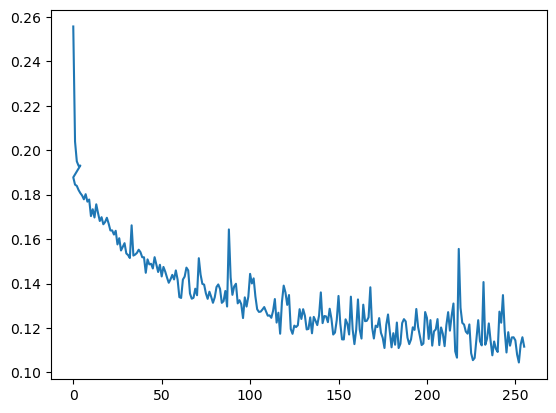

In [20]:
#Earlier Err rate saturated at 20% -> 12.5% -> (<=11%)
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  

import matplotlib.pyplot as plt

plt.plot(model.histY, model.histX)
plt.show()

In [21]:
model.save("AmbSelectorModel.h5")